# Elastic Motion Policy (EMP) — LASA Handwriting Dataset

**Paper**: *Elastic Motion Policy: An Adaptive Dynamical System for Robust and Efficient One-Shot Imitation Learning*  
Li, Sun, Aditya, Figueroa — arXiv 2503.08029v2

---

### What this notebook implements

| Phase | Steps | Purpose |
|-------|-------|---------|
| **1 — Training (offline)** | GMM fit · joint chain · local-frame storage · convex P-QLF · stability SDP | Learn a stable motion policy from **one demonstration** |
| **2 — Update (Phase 2)** | Laplacian edit · velocity-profile regeneration · GMM recovery · P re-estimate · A_k re-solve | Adapt to new scene configuration **without new data** |
| **3 — Runtime** | γ_k(x) · LPV-DS rollout | Evaluate the adapted policy at any query state |

No vision or segmentation components are needed for the LASA task.

---


### Elastic Motion Policy (EMP) — LASA Handwriting Dataset

### Phase 1 (offline) : GMM fitting · joint computation · local-frame storage

In [1]:
import warnings; warnings.filterwarnings("ignore")
import time
import numpy as np
import scipy.linalg as la
from sklearn.mixture import GaussianMixture
import cvxpy as cp
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
np.random.seed(42)

# ── Colour palette ──────────────────────────────────────────────
C_DEMO  = "#3B8BD4"   # blue   — demonstration
C_ORIG  = "#1D9E75"   # teal   — original rollout
C_ADAPT = "#D85A30"   # coral  — adapted rollout
C_GMM   = "#7F77DD"   # purple — Gaussian ellipses
C_JOINT = "#BA7517"   # amber  — joint chain
C_LYPNV = "#639922"   # green  — Lyapunov contours

## Section 1 — DATA LOADING

In [2]:
import pyLasaDataset as lasa

SHAPE_NAME = "CShape"   # try: Sine, GShape, CShape, Worm, Snake, NShape
DEMO_IDX   = 0         # index of the single demonstration used for learning

data  = getattr(lasa.DataSet, SHAPE_NAME)
demo  = data.demos[DEMO_IDX]

pos_raw = demo.pos.T                   # (T, 2)
vel_raw = demo.vel.T                   # (T, 2)
dt_demo = float(demo.dt.flat[0])

print(f"Shape  : {SHAPE_NAME}")
print(f"Points : {pos_raw.shape[0]},  dt = {dt_demo:.5f} s")
print(f"Start  : {pos_raw[0]}")
print(f"End    : {pos_raw[-1]}  (should be ~[0,0])")

Using LASA DataSet from c:\Users\Rayaan_Ghosh\Desktop\IL\project\.venv\Lib\site-packages\pyLasaDataset/resources/LASAHandwritingDataset/DataSet
Shape  : CShape
Points : 1000,  dt = 0.00299 s
Start  : [ 2.81900414 30.30429456]
End    : [0. 0.]  (should be ~[0,0])


## Section 2 — PRE-PROCESSING

In [3]:
x_star = pos_raw[-1].copy()   # attractor

# Subsample to ≤ 300 points (keeps SDP tractable)
N_MAX = 300
idx   = np.round(np.linspace(0, len(pos_raw) - 1, N_MAX)).astype(int)
pos   = pos_raw[idx]                          # (N_MAX, 2)

# Centred finite-difference velocities (cleaner than raw field)
vel   = np.gradient(pos, axis=0) / dt_demo   # (N_MAX, 2)

# Drop last row (velocity at attractor is 0)
X    = pos[:-1]     # (N-1, 2)
Xdot = vel[:-1]     # (N-1, 2)
N    = len(X)

print(f"Training set: {N} (x, ẋ) pairs  |  x* = {x_star}")

Training set: 299 (x, ẋ) pairs  |  x* = [0. 0.]


## Section 3 — GMM FITTING (BIC selection, trajectory-sorted)

In [4]:
def fit_gmm_bic(X, k_min=2, k_max=10, n_init=5):
    """Select K by BIC over k_min … k_max, return fitted GaussianMixture."""
    best_gmm, best_bic = None, np.inf
    for k in range(k_min, k_max + 1):
        gmm = GaussianMixture(n_components=k, covariance_type="full",
                              n_init=n_init, random_state=42)
        gmm.fit(X)
        bic = gmm.bic(X)
        if bic < best_bic:
            best_bic, best_gmm = bic, gmm
    return best_gmm


def sort_gmm_along_trajectory(gmm, x_start, x_end):
    """Sort components by projection onto start→end direction."""
    d = x_end - x_start
    norm = np.linalg.norm(d)
    if norm < 1e-12:
        return np.arange(gmm.n_components)
    return np.argsort(gmm.means_ @ (d / norm))


gmm   = fit_gmm_bic(X, k_min=2, k_max=6)
K     = gmm.n_components
order = sort_gmm_along_trajectory(gmm, X[0], x_star)

means_  = gmm.means_[order]
covs_   = gmm.covariances_[order]
priors_ = gmm.weights_[order]
priors_ /= priors_.sum()

print(f"\nSelected K = {K} GMM components")
for k in range(K):
    print(f"  μ_{k} = {np.round(means_[k], 2)}   π_{k} = {priors_[k]:.3f}")


Selected K = 6 GMM components
  μ_0 = [-1.53 33.02]   π_0 = 0.230
  μ_1 = [-21.26  32.8 ]   π_1 = 0.139
  μ_2 = [-34.63  20.28]   π_2 = 0.188
  μ_3 = [-31.76   3.91]   π_3 = 0.156
  μ_4 = [-3.64 -0.26]   π_4 = 0.184
  μ_5 = [-18.38  -0.97]   π_5 = 0.103


## Section 4 — GMM RESPONSIBILITIES

In [5]:
def compute_gamma_batch(X, means, covs, priors):
    """
    Compute GMM responsibilities γ_k(x) for all rows of X.
    Uses log-sum-exp for numerical stability.
    Returns: (N, K)
    """
    N_q, K_q = len(X), len(means)
    log_p = np.zeros((N_q, K_q))
    for k in range(K_q):
        diff    = X - means[k]
        cov_inv = np.linalg.inv(covs[k])
        log_det = np.linalg.slogdet(covs[k])[1]
        maha    = np.einsum('ni,ij,nj->n', diff, cov_inv, diff)
        log_p[:, k] = (np.log(priors[k] + 1e-300)
                       - 0.5 * (2 * np.log(2 * np.pi) + log_det + maha))
    log_p -= log_p.max(axis=1, keepdims=True)
    p      = np.exp(log_p)
    return p / (p.sum(axis=1, keepdims=True) + 1e-300)


def compute_gamma_single(x, means, covs, priors):
    """Responsibilities for one query point. Returns (K,)."""
    return compute_gamma_batch(x[np.newaxis], means, covs, priors)[0]

## Section 5 — JOINT CHAIN (Eq. 7-8, EMP paper)

In [6]:
def compute_joints(means, covs, x_start, x_end):
    """
    Build the K+1 joint chain  β_0, β_1, …, β_K  where:
      β_0           = x_start
      β_{k,k+1}     = precision-weighted midpoint of Gaussian k and k+1
      β_K           = x_end  (attractor)

    Returns joints : (K+1, 2)
    """
    K_j = len(means)
    interior = []
    for k in range(K_j - 1):
        Si  = np.linalg.inv(covs[k])
        Si1 = np.linalg.inv(covs[k + 1])
        St  = np.linalg.inv(Si + Si1)
        beta = St @ (Si @ means[k] + Si1 @ means[k + 1])
        interior.append(beta)
    rows = ([x_start[np.newaxis]]
            + ([np.array(interior)] if interior else [])
            + [x_end[np.newaxis]])
    return np.vstack(rows)   # (K+1, 2)


joints0 = compute_joints(means_, covs_, X[0], x_star)

print("\nJoint chain (β_0 … β_K):")
for i, b in enumerate(joints0):
    print(f"  β_{i} = {np.round(b, 3)}")


Joint chain (β_0 … β_K):
  β_0 = [ 2.819 30.304]
  β_1 = [-11.86   35.826]
  β_2 = [-31.388  29.479]
  β_3 = [-37.636  10.674]
  β_4 = [-25.55   -2.491]
  β_5 = [-11.788  -1.118]
  β_6 = [0. 0.]


## Section 6 — LOCAL-FRAME STORAGE (Γ_k)

In [7]:
def local_frame_R(joint_a, joint_b):
    """
    2-D orthonormal frame at joint_a, x-axis toward joint_b.
    Returns R (2×2), dist (scalar).
    """
    e_x  = joint_b - joint_a
    dist = np.linalg.norm(e_x)
    if dist < 1e-12: # joints are identical
        return np.eye(2), 0.0
    e_x /= dist
    e_y  = np.array([-e_x[1], e_x[0]])   # CCW 90°
    return np.column_stack([e_x, e_y]), dist


def store_local_frames(means, covs, joints):
    """
    For each Gaussian k (between joints[k] and joints[k+1]) record:
      mu_local : mean relative to local frame origin & rotation
      E_local  : eigenvectors in local frame (columns)
      eigvals  : eigenvalues (scaled with link-length change later)
      dist     : original link length  ‖β_{k+1} − β_k‖
    Returns list of K dicts.
    """
    K_f = len(means)
    frames = []
    for k in range(K_f):
        R, dist  = local_frame_R(joints[k], joints[k + 1])
        mu_local = R.T @ (means[k] - joints[k])
        eigvals, E = np.linalg.eigh(covs[k])   # ascending eigenvalues
        E_local  = R.T @ E
        frames.append(dict(mu_local=mu_local, E_local=E_local,
                           eigvals=eigvals, dist=dist))
    return frames


frames0 = store_local_frames(means_, covs_, joints0)

## Section 7 — LAPLACIAN MATRIX & COORDINATES

In [8]:
def build_laplacian(n):
    """
    Normalised path-graph Laplacian for n+1 nodes.
    Diagonal = 1; off-diagonal = −1 (endpoints, degree 1)
                                    −½ (interior, degree 2).
    Returns L : (n+1, n+1)
    """
    L = np.zeros((n + 1, n + 1))
    for i in range(n + 1):
        if i == 0:
            L[0, 0], L[0, 1] = 1.0, -1.0
        elif i == n:
            L[n, n], L[n, n - 1] = 1.0, -1.0
        else:
            L[i, i]     =  1.0
            L[i, i - 1] = -0.5
            L[i, i + 1] = -0.5
    return L


n_chain = K              # K+1 joints → chain length = K
L_mat   = build_laplacian(n_chain)
Delta0  = L_mat @ joints0

print(f"\nLaplacian (K={K}):\n{np.round(L_mat, 2)}")


Laplacian (K=6):
[[ 1.  -1.   0.   0.   0.   0.   0. ]
 [-0.5  1.  -0.5  0.   0.   0.   0. ]
 [ 0.  -0.5  1.  -0.5  0.   0.   0. ]
 [ 0.   0.  -0.5  1.  -0.5  0.   0. ]
 [ 0.   0.   0.  -0.5  1.  -0.5  0. ]
 [ 0.   0.   0.   0.  -0.5  1.  -0.5]
 [ 0.   0.   0.   0.   0.  -1.   1. ]]


## Section 8 — VELOCITY PROFILE FROM JOINT CHAIN (§4.2, Elastic-DS)

After Laplacian editing produces new joints β*, we generate a synthetic
reference trajectory that passes through β* by interpolating a piecewise
linear path, then computing finite-difference velocities.  This is the
"Create Velocity Profile" step from the Elastic-DS paper and is used as
the velocity reference Xdot when re-estimating P and A_k.

In [9]:
def create_velocity_profile(joints, N_pts=250, dt=0.01):
    """
    Generate a reference trajectory that passes through the joint chain
    via Laplacian editing (Eq. 8, Elastic-DS paper):

      min_ζ  ‖L_ζ ζ − Δ_ζ‖²    s.t.  ζ[j] = β_q  for each joint q

    Practical implementation: parameterise by arc-length fraction,
    map each joint to its corresponding index in a uniform N_pts grid,
    then solve a constrained least-squares problem to smooth the path.

    Returns
    -------
    pos_ref  : (N_pts, 2) reference positions
    vel_ref  : (N_pts, 2) finite-difference velocities
    """
    n_j   = len(joints)             # K+1
    # Total arc-length of the piecewise-linear joint path
    segs  = np.diff(joints, axis=0)
    dists = np.linalg.norm(segs, axis=1)
    total = dists.sum()
    if total < 1e-12:
        pos_ref = np.tile(joints[0], (N_pts, 1))
        vel_ref = np.zeros((N_pts, 2))
        return pos_ref, vel_ref

    # Cumulative fractional arc-length at each joint → index in [0, N_pts-1]
    cum   = np.concatenate([[0.0], np.cumsum(dists)])
    lam   = cum / total                          # (n_j,) in [0,1]
    idx_j = np.round(lam * (N_pts - 1)).astype(int)
    idx_j = np.clip(idx_j, 0, N_pts - 1)

    # Start with the piecewise-linear interpolation as initial guess
    t_uniform = np.linspace(0, 1, N_pts)
    pos_ref   = np.zeros((N_pts, 2))
    for dim in range(2):
        pos_ref[:, dim] = np.interp(t_uniform, lam, joints[:, dim])

    # Build Laplacian for the N_pts-node path
    L_ref = build_laplacian(N_pts - 1)          # (N_pts, N_pts)
    Delta_ref = L_ref @ pos_ref                  # (N_pts, 2)

    # Solve constrained LS: pin the indices corresponding to joints
    # Build augmented system [L; pin rows] x = [Delta; joint values]
    n_pin    = n_j
    A_aug    = np.vstack([L_ref,
                          np.eye(N_pts)[idx_j]])         # (N_pts+n_pin, N_pts)
    b_aug    = np.vstack([Delta_ref, joints])            # (N_pts+n_pin, 2)
    # Normal equations (fast for moderate N_pts)
    AtA  = A_aug.T @ A_aug
    Atb  = A_aug.T @ b_aug
    pos_ref = np.linalg.lstsq(AtA, Atb, rcond=None)[0]  # (N_pts, 2)

    vel_ref = np.gradient(pos_ref, axis=0) / dt
    return pos_ref, vel_ref


# Verify on original joints
pos_ref0, vel_ref0 = create_velocity_profile(joints0, N_pts=N, dt=dt_demo)
print(f"\nVelocity profile from original joints: {len(pos_ref0)} points")


Velocity profile from original joints: 299 points


## Section 9 — ESTIMATE P VIA CONVEX P-QLF (GMM-informed, §IV.B)

Minimise violations of V̇ = 2ẋᵀP(x − x*) < 0 using K centroid
representatives instead of all N data points → fast QP.

In [10]:
def gmm_centroids(X, Xdot, means, covs, priors):
    """Hard-assign each point to most-likely component; return (x̄_k, ẋ̄_k)."""
    K_c   = len(means)
    gmat  = compute_gamma_batch(X, means, covs, priors)
    assign = np.argmax(gmat, axis=1)
    X_bar, Xdot_bar = [], []
    for k in range(K_c):
        mask = (assign == k)
        X_bar.append(X[mask].mean(axis=0) if mask.sum() > 0 else means[k])
        Xdot_bar.append(Xdot[mask].mean(axis=0) if mask.sum() > 0 else np.zeros(2))
    return np.array(X_bar), np.array(Xdot_bar)


def estimate_P(X_bar, Xdot_bar, x_star, eps=1e-5):
    """
    Convex P-QLF: find P = Pᵀ ≻ 0 minimising Σ_k ReLU(ẋ̄_k·P(x̄_k−x*))
    subject to P ≽ ε I.

    Returns P : (2, 2)
    """
    d, K_c = 2, len(X_bar)
    Z_bar  = X_bar - x_star
    P_var  = cp.Variable((d, d), symmetric=True)
    s_vars = cp.Variable(K_c, nonneg=True)
    cons   = [P_var >> eps * np.eye(d)]
    for k in range(K_c):
        cons.append(s_vars[k] >= Xdot_bar[k] @ P_var @ Z_bar[k])
    prob = cp.Problem(cp.Minimize(cp.sum(s_vars)), cons)
    prob.solve(solver=cp.SCS, verbose=False, eps=1e-5)
    P_val = P_var.value
    if P_val is None or not np.all(np.isfinite(P_val)):
        P_val = np.eye(d)
    P_val = np.array(P_val, dtype=float).reshape(d, d)
    P_val = 0.5 * (P_val + P_val.T)
    eigmin = float(np.linalg.eigvalsh(P_val).min())
    _eps = float(np.asarray(eps).flat[0])
    if eigmin < _eps:
        P_val += (_eps - eigmin + 1e-8) * np.eye(d)
    return P_val


X_bar0, Xdot_bar0 = gmm_centroids(X, Xdot, means_, covs_, priors_)
t0 = time.perf_counter()
P_val = estimate_P(X_bar0, Xdot_bar0, x_star)
t_P_gmm = time.perf_counter() - t0

print(f"\nP (GMM-informed):\n{np.round(P_val, 4)}")
print(f"eigenvalues(P) = {np.round(np.linalg.eigvalsh(P_val), 4)}  (both > 0 ✓)")
print(f"Estimation time (K={K} centroids): {t_P_gmm*1000:.1f} ms")


P (GMM-informed):
[[0.0128 0.0076]
 [0.0076 0.0194]]
eigenvalues(P) = [0.0078 0.0244]  (both > 0 ✓)
Estimation time (K=6 centroids): 47.4 ms


## Section 10 — ESTIMATE {A_k} VIA STABILITY-CONSTRAINED SDP (Eq. 3)

min_{A_k}  ‖Ẋ − Σ_k diag(γ_k) Z A_kᵀ‖_F²
s.t.       A_kᵀ P + P A_k ≼ −ε I   ∀k

In [11]:
def estimate_Ak(X, Xdot, means, covs, priors, P, x_star, eps_stab=1e-4):
    """
    Stability-constrained SDP for {A_k}.
    Uses local K_loc = len(means) to avoid any outer-scope K.
    Returns list of K_loc (2×2) arrays.
    """
    K_loc = len(means)
    d     = 2
    Z     = X - x_star                                      # (N, 2)
    gmat  = compute_gamma_batch(X, means, covs, priors)     # (N, K_loc)
    A_vars = [cp.Variable((d, d)) for _ in range(K_loc)]

    Xdot_pred = sum(
        cp.multiply(gmat[:, k:k+1], Z @ A_vars[k].T)
        for k in range(K_loc)
    )
    objective   = cp.Minimize(cp.sum_squares(Xdot - Xdot_pred) / len(X))
    constraints = []
    for k in range(K_loc):
        lmi = A_vars[k].T @ P + P @ A_vars[k]
        constraints.append(lmi << -eps_stab * np.eye(d))

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, verbose=False, eps=1e-4, max_iters=15000)

    result = []
    for k in range(K_loc):
        Ak = A_vars[k].value
        if Ak is None or not np.all(np.isfinite(Ak)):
            print(f"  [A_{k}] solver fail — using -I fallback")
            Ak = -np.eye(d)
        result.append(Ak)
    return result


t0 = time.perf_counter()
A_vals = estimate_Ak(X, Xdot, means_, covs_, priors_, P_val, x_star)
t_Ak = time.perf_counter() - t0

print(f"\nA_k SDP time (N={N}, K={K}): {t_Ak*1000:.1f} ms")
print("Stability check (all eigenvalues of A_kᵀP + PA_k must be < 0):")
all_stable = True
for k in range(K):
    eigs = np.linalg.eigvals(A_vals[k].T @ P_val + P_val @ A_vals[k]).real
    ok   = (eigs < 0).all()
    all_stable = all_stable and ok
    print(f"  A_{k}: eigvals = {np.round(eigs, 5)}  {'✓' if ok else '✗'}")


A_k SDP time (N=299, K=6): 42.0 ms
Stability check (all eigenvalues of A_kᵀP + PA_k must be < 0):
  A_0: eigvals = [ 3.00e-05 -5.48e-03]  ✗
  A_1: eigvals = [-0.00071 -0.0614 ]  ✓
  A_2: eigvals = [-0.00035 -0.08768]  ✓
  A_3: eigvals = [ 9.0000e-05 -4.8698e-01]  ✗
  A_4: eigvals = [-2.00000e-05 -1.49536e+00]  ✓
  A_5: eigvals = [ 3.80000e-04 -1.09259e+00]  ✗


## Section 11 — LPV-DS VELOCITY & ROLLOUT

In [12]:
def lpv_ds_velocity(x, means, covs, priors, A_vals, x_star,
                     global_gain=1.5):
    """
    ẋ = Σ_k γ_k(x) A_k (x − x*)  at a single state x.

    A weighted global attraction term −g(x)·(x − x*) is added, where
    g(x) = global_gain · (1 − max_k γ_k(x)).  This ensures non-zero
    velocity in regions far outside the Gaussian support, which can
    occur in OOD rollouts.  The term vanishes inside the GMM support
    (where max γ_k ≈ 1) so it does not distort the learned shape.
    """
    gamma   = compute_gamma_single(x, means, covs, priors)
    z       = x - x_star
    v_lpvds = sum(gamma[k] * (A_vals[k] @ z) for k in range(len(A_vals)))
    g_ood   = global_gain * (1.0 - float(gamma.max()))
    return v_lpvds - g_ood * z


def rollout(x0, means, covs, priors, A_vals, x_star,
            dt=0.005, max_steps=10000, tol=0.05):
    """
    Forward-Euler integration of the LPV-DS from x0.
    Stops when ‖x − x*‖ < tol or max_steps reached.
    Returns trajectory (T, 2).
    """
    x    = x0.copy()
    traj = [x.copy()]
    for _ in range(max_steps):
        xdot = lpv_ds_velocity(x, means, covs, priors, A_vals, x_star)
        # Adaptive step: clip velocity magnitude to avoid overshooting
        spd  = np.linalg.norm(xdot)
        if spd > 1e-10:
            xdot = xdot * min(1.0, 500.0 / spd)   # cap at 500 units/s
        x = x + dt * xdot
        traj.append(x.copy())
        if np.linalg.norm(x - x_star) < tol:
            break
    return np.array(traj)


traj_orig = rollout(X[0], means_, covs_, priors_, A_vals, x_star)
print(f"\nOriginal rollout: {len(traj_orig)} steps, "
      f"final = {np.round(traj_orig[-1], 3)}, "
      f"dist to x* = {np.linalg.norm(traj_orig[-1] - x_star):.4f}")


Original rollout: 212 steps, final = [-0.049 -0.004], dist to x* = 0.0491


## Section 12 — LYAPUNOV VERIFICATION

In [13]:
def lyapunov_violation_rate(X, Xdot, P, x_star):
    """Fraction of points where V̇ = 2ẋᵀP(x−x*) ≥ 0."""
    Z    = X - x_star
    Vdot = 2.0 * np.einsum('ni,ij,nj->n', Xdot, P, Z)
    return float((Vdot >= 0).sum()) / len(X)


gmat_orig  = compute_gamma_batch(X, means_, covs_, priors_)
Z_train    = X - x_star
Xdot_pred  = sum(gmat_orig[:, k:k+1] * (Z_train @ A_vals[k].T)
                 for k in range(K))
viol_orig  = lyapunov_violation_rate(X, Xdot_pred, P_val, x_star)
print(f"Lyapunov violation rate (training): {100*viol_orig:.1f}%")

Lyapunov violation rate (training): 0.0%


## Section 13 — LAPLACIAN EDITING 

In [14]:
def laplacian_edit(joints, L, Delta, new_start, new_end):
    """
    Solve:  min_β*  ‖L β* − Δ‖_F²
            s.t.    β*_0 = new_start,  β*_n = new_end

    Interior nodes β*_1 … β*_{n-1} are obtained from the interior rows
    of L β* = Δ with endpoint columns moved to the RHS.

    Returns joints_new : (K+1, 2)
    """
    n = len(joints) - 1   # K
    if n == 1:
        return np.vstack([new_start, new_end])

    # Interior block: rows 1..n-1, columns 1..n-1
    L_int    = L[1:n, 1:n]       # (n-1, n-1)
    L_col0   = L[1:n, 0]         # (n-1,)
    L_coln   = L[1:n, n]         # (n-1,)
    Delta_int = Delta[1:n]        # (n-1, 2)

    RHS = (Delta_int
           - np.outer(L_col0, new_start)
           - np.outer(L_coln, new_end))   # (n-1, 2)

    beta_int = np.linalg.solve(L_int, RHS)  # (n-1, 2)
    return np.vstack([new_start, beta_int, new_end])

## Section 14 — RECOVER UPDATED GMM 

In [15]:
def recover_gmm(joints_new, frames, priors):
    """
    Recover updated (means*, covs*) from new joints using stored Γ_k.

    μ*_k = β*_k + R*_k · (R_k^orig)^T · (μ_k − β_k)   [=R*_k · mu_local]
    Σ*_k = E*_k diag(λ_k · s_k) (E*_k)^T              where s_k = d*_k/d_k
    π*_k = π_k   (unchanged)

    Returns means_new (K,2), covs_new (K,2,2), priors (K,)
    """
    K_r = len(frames)
    means_new, covs_new = [], []
    for k in range(K_r):
        R_new, dist_new = local_frame_R(joints_new[k], joints_new[k + 1])
        d_old = frames[k]["dist"]
        s     = dist_new / d_old if d_old > 1e-12 else 1.0

        mu_new = joints_new[k] + R_new @ frames[k]["mu_local"]
        means_new.append(mu_new)

        E_new      = R_new @ frames[k]["E_local"]
        eigvals_s  = np.maximum(frames[k]["eigvals"] * s, 1e-8)
        cov_new    = E_new @ np.diag(eigvals_s) @ E_new.T
        cov_new    = 0.5 * (cov_new + cov_new.T)
        covs_new.append(cov_new)

    return np.array(means_new), np.array(covs_new), priors.copy()

## Section 15 — FULL ADAPTATION PIPELINE 

In [16]:
def adapt_emp(new_start, new_x_star,
              joints_orig, L_mat, Delta0,
              frames_orig, priors,
              X_train, Xdot_train,
              eps_P=1e-5, eps_stab=1e-3, N_vel=250):
    """
    Full EMP update:
      1. Laplacian edit joints
      2. Regenerate velocity profile through edited joints   ← §4.2 Elastic-DS
      3. Recover updated GMM {μ*_k, Σ*_k, π_k}
      4. Re-estimate P (GMM-informed convex QP)
      5. Re-estimate {A*_k} (stability-constrained SDP)

    Returns dict with keys: joints, means, covs, priors, P, A_vals, x_star
    """
    # Step 1 — Laplacian editing
    joints_new = laplacian_edit(joints_orig, L_mat, Delta0,
                                new_start, new_x_star)

    # Step 2 — Velocity profile through edited joint chain
    pos_ref, vel_ref = create_velocity_profile(joints_new,
                                               N_pts=N_vel,
                                               dt=dt_demo)
    # Use edited trajectory as training reference for P and A_k
    X_ref    = pos_ref[:-1]
    Xdot_ref = vel_ref[:-1]

    # Step 3 — Recover updated GMM
    means_new, covs_new, priors_new = recover_gmm(joints_new, frames_orig,
                                                   priors)

    # Step 4 — P re-estimation (K centroids of updated GMM)
    # Blend velocity-profile data with the original training data so that
    # the Lyapunov estimate is informed by both the new geometry and the
    # original velocity magnitudes (prevents over-weak or degenerate P).
    X_blend    = np.vstack([X_ref,    X_train])
    Xdot_blend = np.vstack([Xdot_ref, Xdot_train])
    X_bar_new, Xdot_bar_new = gmm_centroids(X_blend, Xdot_blend,
                                             means_new, covs_new, priors_new)
    P_new = estimate_P(X_bar_new, Xdot_bar_new, new_x_star, eps=eps_P)

    # Step 5 — A_k re-estimation on blended data
    A_new = estimate_Ak(X_blend, Xdot_blend,
                        means_new, covs_new, priors_new,
                        P_new, new_x_star, eps_stab=eps_stab)

    return dict(joints=joints_new, means=means_new, covs=covs_new,
                priors=priors_new, P=P_new, A_vals=A_new,
                x_star=new_x_star, pos_ref=pos_ref)

## Section 16 — THREE ADAPTATION SCENARIOS

In [17]:
span_x = pos[:, 0].max() - pos[:, 0].min()
span_y = pos[:, 1].max() - pos[:, 1].min()

scenarios = {
    "A — new start": dict(
        new_start  = X[0] + np.array([ 0.45 * span_x, -0.30 * span_y]),
        new_x_star = x_star.copy()
    ),
    "B — new goal": dict(
        new_start  = X[0].copy(),
        new_x_star = x_star + np.array([ 0.40 * span_x,  0.40 * span_y])
    ),
    "C — full OOD": dict(
        new_start  = X[0] + np.array([-0.30 * span_x,  0.45 * span_y]),
        new_x_star = x_star + np.array([ 0.45 * span_x, -0.30 * span_y])
    ),
}

print("\n" + "=" * 60)
print("ADAPTATION RUNS")
print("=" * 60)
adapted_policies = {}
for label, sc in scenarios.items():
    print(f"\n── {label} ──")
    t0 = time.perf_counter()
    policy = adapt_emp(
        new_start   = sc["new_start"],
        new_x_star  = sc["new_x_star"],
        joints_orig = joints0,
        L_mat       = L_mat,
        Delta0      = Delta0,
        frames_orig = frames0,
        priors      = priors_,
        X_train     = X,
        Xdot_train  = Xdot,
    )
    t_adapt = time.perf_counter() - t0

    traj = rollout(sc["new_start"], policy["means"], policy["covs"],
                   policy["priors"], policy["A_vals"], policy["x_star"])
    policy["traj"]      = traj
    policy["new_start"] = sc["new_start"]
    adapted_policies[label] = policy

    # Report
    P_sc = policy["P"]
    any_unstable = False
    for k, Ak in enumerate(policy["A_vals"]):
        eigs = np.linalg.eigvals(Ak.T @ P_sc + P_sc @ Ak).real
        ok   = (eigs < 0).all()
        any_unstable = any_unstable or not ok
        print(f"  A_{k} {'✓' if ok else '✗'}  eigvals = {np.round(eigs, 4)}")
    viol = lyapunov_violation_rate(
        policy["pos_ref"][:-1],
        np.gradient(policy["pos_ref"], axis=0)[:-1] / dt_demo,
        P_sc, policy["x_star"])
    dist = np.linalg.norm(traj[-1] - policy["x_star"])
    print(f"  Total adapt time : {t_adapt*1000:.0f} ms")
    print(f"  Lyapunov viol.   : {100*viol:.1f}%")
    print(f"  Rollout steps    : {len(traj)}   final dist to x* : {dist:.4f}")


ADAPTATION RUNS

── A — new start ──
  A_0 ✓  eigvals = [-0.001 -0.01 ]
  A_1 ✓  eigvals = [-0.0017 -0.0354]
  A_2 ✓  eigvals = [-0.0009 -0.0259]
  A_3 ✓  eigvals = [-0.0092 -0.1301]
  A_4 ✓  eigvals = [-0.1914 -0.001 ]
  A_5 ✓  eigvals = [-1.1000e-03 -1.3835e+00]
  Total adapt time : 625 ms
  Lyapunov viol.   : 19.3%
  Rollout steps    : 236   final dist to x* : 0.0472

── B — new goal ──
  A_0 ✓  eigvals = [-0.0016 -0.001 ]
  A_1 ✓  eigvals = [-0.0029 -0.0011]
  A_2 ✓  eigvals = [-0.0003 -0.0011]
  A_3 ✓  eigvals = [-0.0008 -0.0011]
  A_4 ✓  eigvals = [-0.002 -0.001]
  A_5 ✓  eigvals = [-0.0013 -0.001 ]
  Total adapt time : 275 ms
  Lyapunov viol.   : 23.3%
  Rollout steps    : 39   final dist to x* : 0.0351

── C — full OOD ──
  A_0 ✓  eigvals = [-0.0024 -0.001 ]
  A_1 ✓  eigvals = [-0.0015 -0.038 ]
  A_2 ✗  eigvals = [ 0.0005 -0.0256]
  A_3 ✓  eigvals = [-0.0009 -0.0317]
  A_4 ✓  eigvals = [-0.0013 -0.4119]
  A_5 ✓  eigvals = [-0.0045 -0.001 ]
  Total adapt time : 1231 ms
  Lyapun

## Section 17 — PLOTTING UTILITIES

In [18]:
def draw_ellipse(ax, mean, cov, n_std=1.5, **kw):
    eigvals, eigvecs = np.linalg.eigh(cov)
    angle  = np.degrees(np.arctan2(eigvecs[1, -1], eigvecs[0, -1]))
    w = 2 * n_std * np.sqrt(np.abs(eigvals[-1]))  # major (largest)
    h = 2 * n_std * np.sqrt(np.abs(eigvals[0]))   # minor (smallest)
    ax.add_patch(Ellipse(xy=mean, width=w, height=h, angle=angle, **kw))


def pad(arr, frac=0.18):
    lo, hi = arr.min(), arr.max()
    m = frac * max(hi - lo, 1e-3)
    return lo - m, hi + m


def vector_field_grid(means, covs, priors, A_vals, x_star,
                      xlim, ylim, n=16):
    xs, ys  = np.linspace(*xlim, n), np.linspace(*ylim, n)
    Xg, Yg  = np.meshgrid(xs, ys)
    U, V    = np.zeros_like(Xg), np.zeros_like(Yg)
    for i in range(n):
        for j in range(n):
            xv   = np.array([Xg[i, j], Yg[i, j]])
            dv   = lpv_ds_velocity(xv, means, covs, priors, A_vals, x_star)
            spd  = np.linalg.norm(dv) + 1e-9
            U[i, j], V[i, j] = dv[0] / spd, dv[1] / spd
    return Xg, Yg, U, V


def lyapunov_grid(x_star, P, xlim, ylim, n=200):
    xs, ys  = np.linspace(*xlim, n), np.linspace(*ylim, n)
    Xg, Yg  = np.meshgrid(xs, ys)
    Zg      = np.stack([Xg - x_star[0], Yg - x_star[1]], axis=-1)
    Vg      = np.einsum('...i,ij,...j->...', Zg, P, Zg)
    return Xg, Yg, Vg

## Section 18 — FIGURE 1: ORIGINAL POLICY

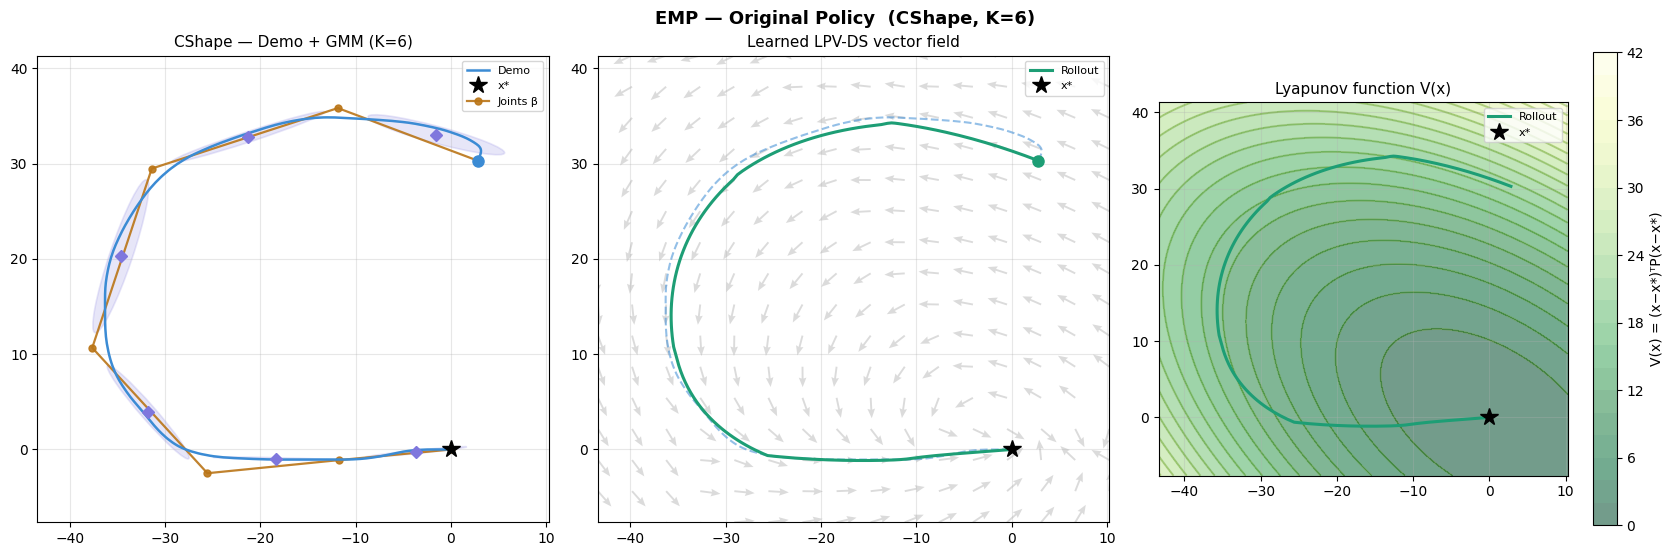

Saved: emp_original_policy.png


In [19]:
all_pts  = np.vstack([pos, traj_orig])
xlim_o   = pad(all_pts[:, 0])
ylim_o   = pad(all_pts[:, 1])

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# Panel A — Demo + GMM + joint chain
ax = axes[0]
ax.plot(pos[:, 0], pos[:, 1], color=C_DEMO, lw=1.8, zorder=3, label="Demo")
ax.plot(*pos[0],  'o', color=C_DEMO,  ms=8,  zorder=5)
ax.plot(*x_star,  '*', color="black", ms=13, zorder=5, label="x*")
for k in range(K):
    draw_ellipse(ax, means_[k], covs_[k],
                 fc=C_GMM, alpha=0.18, ec=C_GMM, lw=1.2)
    ax.plot(*means_[k], 'D', color=C_GMM, ms=6, zorder=4)
ax.plot(joints0[:, 0], joints0[:, 1], '-o', color=C_JOINT,
        lw=1.6, ms=5, alpha=0.9, label="Joints β")
ax.set_title(f"{SHAPE_NAME} — Demo + GMM (K={K})", fontsize=11)
ax.set_xlim(xlim_o); ax.set_ylim(ylim_o)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="best")

# Panel B — Vector field + rollout
ax = axes[1]
Xg, Yg, U, V = vector_field_grid(means_, covs_, priors_, A_vals, x_star,
                                  xlim_o, ylim_o)
ax.quiver(Xg, Yg, U, V, alpha=0.28, color="gray", scale=25, headwidth=4)
ax.plot(pos[:, 0], pos[:, 1], color=C_DEMO, lw=1.5, alpha=0.55, ls="--")
ax.plot(traj_orig[:, 0], traj_orig[:, 1], color=C_ORIG, lw=2.2, label="Rollout")
ax.plot(*X[0],   'o', color=C_ORIG,  ms=8)
ax.plot(*x_star, '*', color="black", ms=13, label="x*")
ax.set_title("Learned LPV-DS vector field", fontsize=11)
ax.set_xlim(xlim_o); ax.set_ylim(ylim_o)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Panel C — Lyapunov level sets
ax = axes[2]
Xg, Yg, Vg = lyapunov_grid(x_star, P_val, xlim_o, ylim_o)
cs = ax.contourf(Xg, Yg, Vg, levels=20, cmap="YlGn_r", alpha=0.55)
ax.contour(Xg, Yg, Vg, levels=20, colors=C_LYPNV, alpha=0.4, lw=0.8)
plt.colorbar(cs, ax=ax, label="V(x) = (x−x*)ᵀP(x−x*)")
ax.plot(traj_orig[:, 0], traj_orig[:, 1], color=C_ORIG, lw=2.2, label="Rollout")
ax.plot(*x_star, '*', color="black", ms=13, label="x*")
ax.set_title("Lyapunov function V(x)", fontsize=11)
ax.set_xlim(xlim_o); ax.set_ylim(ylim_o)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.suptitle(f"EMP — Original Policy  ({SHAPE_NAME}, K={K})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/emp_original_policy.png",
#          dpi=150, bbox_inches="tight")
plt.show()
print("Saved: emp_original_policy.png")

## Section 19 — FIGURE 2: ADAPTATION COMPARISON

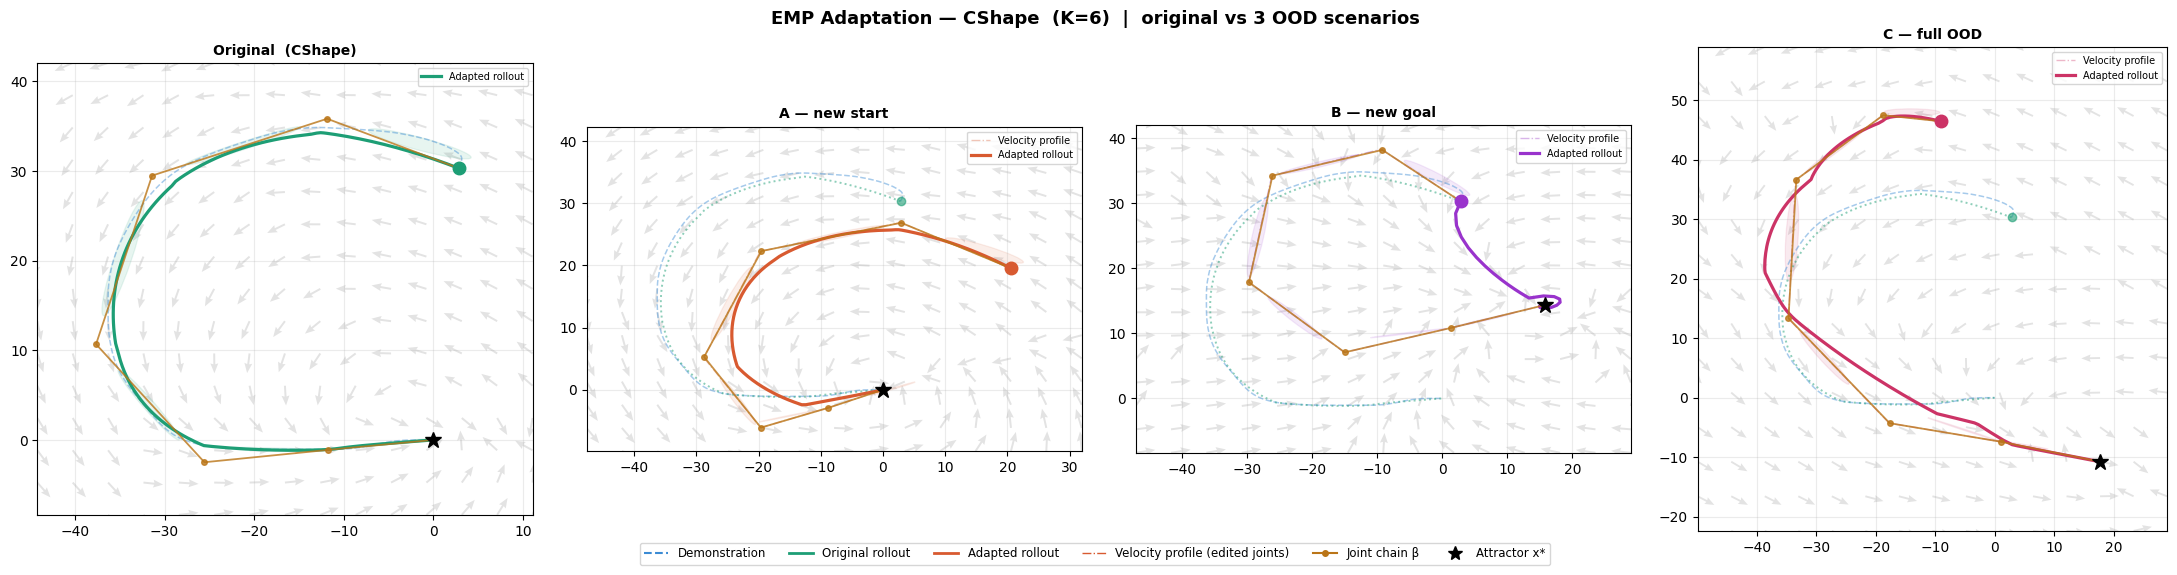

Saved: emp_adaptations.png


In [20]:
def plot_policy_panel(ax, title,
                      means, covs, priors, A_vals, x_star,
                      traj, start, joints,
                      pos_ref=None, demo_pos=None,
                      orig_traj=None, orig_start=None,
                      adapt_color=C_ADAPT):
    pts = [traj]
    if demo_pos  is not None: pts.append(demo_pos)
    if orig_traj is not None: pts.append(orig_traj)
    all_p = np.vstack(pts)
    xl = pad(all_p[:, 0], 0.20)
    yl = pad(all_p[:, 1], 0.20)

    Xg, Yg, U, V = vector_field_grid(means, covs, priors, A_vals,
                                      x_star, xl, yl, n=15)
    ax.quiver(Xg, Yg, U, V, alpha=0.22, color="gray", scale=25, headwidth=4)

    if demo_pos is not None:
        ax.plot(demo_pos[:, 0], demo_pos[:, 1],
                color=C_DEMO, lw=1.1, alpha=0.45, ls="--")
    if orig_traj is not None:
        ax.plot(orig_traj[:, 0], orig_traj[:, 1],
                color=C_ORIG, lw=1.4, alpha=0.50, ls=":")
        if orig_start is not None:
            ax.plot(*orig_start, 'o', color=C_ORIG, ms=6, alpha=0.6)
    if pos_ref is not None:
        ax.plot(pos_ref[:, 0], pos_ref[:, 1],
                color=adapt_color, lw=1.0, alpha=0.35, ls="-.",
                label="Velocity profile")

    ax.plot(traj[:, 0], traj[:, 1], color=adapt_color, lw=2.3,
            label="Adapted rollout")

    for k in range(len(means)):
        draw_ellipse(ax, means[k], covs[k], n_std=1.2,
                     fc=adapt_color, alpha=0.10, ec=adapt_color, lw=0.9)

    ax.plot(joints[:, 0], joints[:, 1], '-o', color=C_JOINT,
            lw=1.3, ms=4, alpha=0.80)
    ax.plot(*start,   'o', color=adapt_color, ms=9, zorder=5)
    ax.plot(*x_star,  '*', color="black", ms=12, zorder=5)

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlim(xl); ax.set_ylim(yl)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7, loc="best")


sc_colors = [C_ADAPT, "#9933CC", "#CC3366"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

# Column 0: original policy
plot_policy_panel(
    axes[0], f"Original  ({SHAPE_NAME})",
    means_, covs_, priors_, A_vals, x_star,
    traj_orig, X[0], joints0,
    demo_pos=pos, orig_traj=None,
    adapt_color=C_ORIG)

# Columns 1-3: adapted policies
for idx, (label, policy) in enumerate(adapted_policies.items()):
    plot_policy_panel(
        axes[idx + 1], label,
        policy["means"], policy["covs"], policy["priors"],
        policy["A_vals"], policy["x_star"],
        policy["traj"], policy["new_start"], policy["joints"],
        pos_ref=policy["pos_ref"],
        demo_pos=pos, orig_traj=traj_orig, orig_start=X[0],
        adapt_color=sc_colors[idx])

legend_el = [
    Line2D([0],[0], color=C_DEMO,  lw=1.5, ls="--",  label="Demonstration"),
    Line2D([0],[0], color=C_ORIG,  lw=2.0,            label="Original rollout"),
    Line2D([0],[0], color=C_ADAPT, lw=2.0,            label="Adapted rollout"),
    Line2D([0],[0], color=C_ADAPT, lw=1.0, ls="-.",   label="Velocity profile (edited joints)"),
    Line2D([0],[0], color=C_JOINT, lw=1.5, marker="o", ms=4, label="Joint chain β"),
    Line2D([0],[0], color="black", lw=0, marker="*",  ms=10, label="Attractor x*"),
]
fig.legend(handles=legend_el, loc="lower center", ncol=6,
           fontsize=8.5, bbox_to_anchor=(0.5, -0.04))
plt.suptitle(f"EMP Adaptation — {SHAPE_NAME}  (K={K})  |  original vs 3 OOD scenarios",
             fontsize=13, fontweight="bold")
plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/emp_adaptations.png",
#           dpi=150, bbox_inches="tight")
plt.show()
print("Saved: emp_adaptations.png")

## Section 20 — FIGURE 3: LYAPUNOV COMPARISON

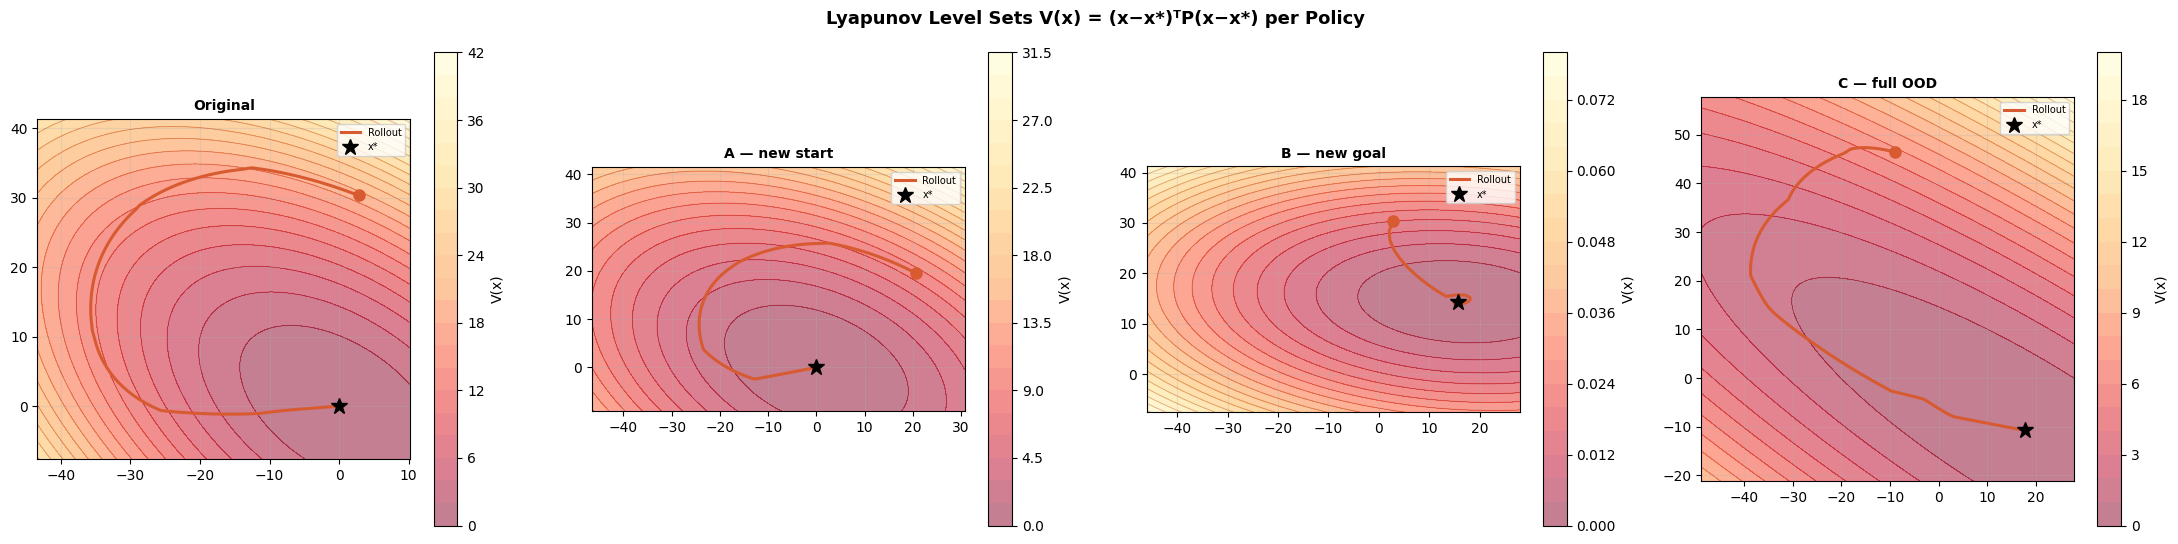

Saved: emp_lyapunov_comparison.png


In [21]:
all_pol = [
    ("Original", dict(means=means_, covs=covs_, priors=priors_,
                      A_vals=A_vals, P=P_val, x_star=x_star,
                      traj=traj_orig, new_start=X[0]))
] + list(adapted_policies.items())

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

for ax, (label, pol) in zip(axes, all_pol):
    traj_  = pol["traj"]
    start_ = pol["new_start"]
    xst_   = pol["x_star"]
    P_     = pol["P"]
    all_p  = np.vstack([pos, traj_])
    xl_ = pad(all_p[:, 0], 0.18)
    yl_ = pad(all_p[:, 1], 0.18)

    Xg_, Yg_, Vg_ = lyapunov_grid(xst_, P_, xl_, yl_, n=200)
    cs_ = ax.contourf(Xg_, Yg_, Vg_, levels=20, cmap="YlOrRd_r", alpha=0.50)
    ax.contour(Xg_, Yg_, Vg_, levels=20, colors="darkred", alpha=0.25, linewidths=0.7)
    plt.colorbar(cs_, ax=ax, label="V(x)")

    ax.plot(traj_[:, 0], traj_[:, 1], color=C_ADAPT, lw=2.2, label="Rollout")
    ax.plot(*start_,  'o', color=C_ADAPT, ms=8)
    ax.plot(*xst_,    '*', color="black",  ms=12, label="x*")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlim(xl_); ax.set_ylim(yl_)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7)

plt.suptitle("Lyapunov Level Sets V(x) = (x−x*)ᵀP(x−x*) per Policy",
             fontsize=13, fontweight="bold")
plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/emp_lyapunov_comparison.png",
#            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: emp_lyapunov_comparison.png")

## Section 21 — FIGURE 4: MULTI-SHAPE DEMO

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/emp_multi_shape.png'

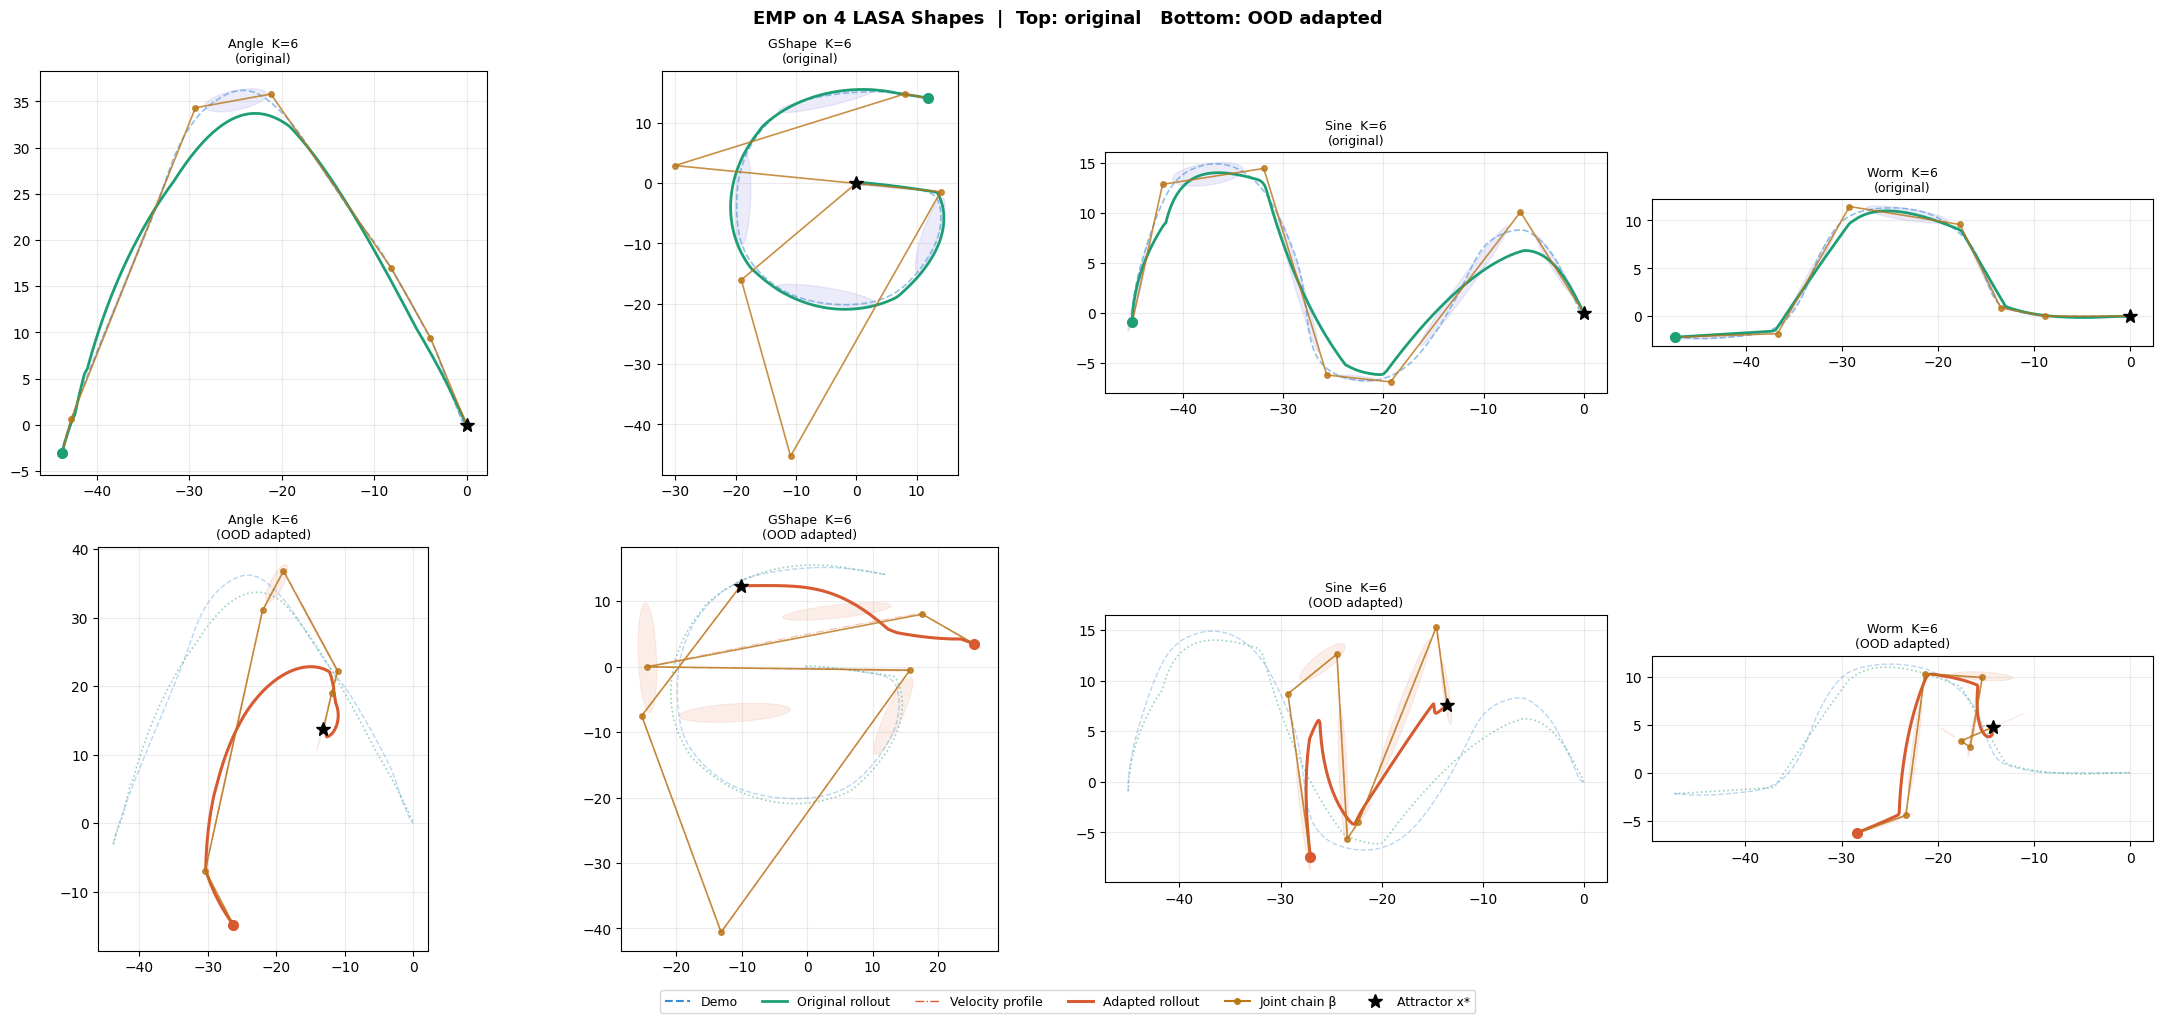

In [ ]:
SHAPES_DEMO = ["Angle", "GShape", "Sine", "Worm"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for col, sname in enumerate(SHAPES_DEMO):
    # ── Load & preprocess ──────────────────────────────────────
    d_    = getattr(lasa.DataSet, sname)
    dem_  = d_.demos[0]
    p_    = dem_.pos.T
    dt_   = float(dem_.dt.flat[0])
    xs_   = p_[-1].copy()
    idx_  = np.round(np.linspace(0, len(p_) - 1, 300)).astype(int)
    P_    = p_[idx_]
    Vd_   = np.gradient(P_, axis=0) / dt_
    X_    = P_[:-1]; Xd_ = Vd_[:-1]

    # ── GMM ────────────────────────────────────────────────────
    g_    = fit_gmm_bic(X_, k_min=2, k_max=6)
    K_    = g_.n_components
    ord_  = sort_gmm_along_trajectory(g_, X_[0], xs_)
    mu_   = g_.means_[ord_]
    cv_   = g_.covariances_[ord_]
    pi_   = g_.weights_[ord_]; pi_ /= pi_.sum()

    # ── Joints, frames, Laplacian ──────────────────────────────
    j0_   = compute_joints(mu_, cv_, X_[0], xs_)
    fr_   = store_local_frames(mu_, cv_, j0_)
    Lm_   = build_laplacian(K_)
    Dl_   = Lm_ @ j0_

    # ── P and A_k ──────────────────────────────────────────────
    Xb_, Xdb_ = gmm_centroids(X_, Xd_, mu_, cv_, pi_)
    Pv_       = estimate_P(Xb_, Xdb_, xs_)
    Av_       = estimate_Ak(X_, Xd_, mu_, cv_, pi_, Pv_, xs_)
    tr0_      = rollout(X_[0], mu_, cv_, pi_, Av_, xs_)

    # ── Adapt: shift both endpoints ─────────────────────────────
    sx_ = P_[:, 0].max() - P_[:, 0].min()
    sy_ = P_[:, 1].max() - P_[:, 1].min()
    ns_ = X_[0] + np.array([ 0.40 * sx_, -0.30 * sy_])
    ne_ = xs_   + np.array([-0.30 * sx_,  0.35 * sy_])
    pol_ = adapt_emp(ns_, ne_, j0_, Lm_, Dl_, fr_, pi_, X_, Xd_, Pv_,
                     N_vel=len(X_))
    tra_ = rollout(ns_, pol_["means"], pol_["covs"],
                   pol_["priors"], pol_["A_vals"], pol_["x_star"])

    # ── Top row: original ───────────────────────────────────────
    ax = axes[0, col]
    ax.plot(p_[:, 0], p_[:, 1], color=C_DEMO, lw=1.2, alpha=0.55, ls="--")
    ax.plot(tr0_[:, 0], tr0_[:, 1], color=C_ORIG, lw=2.0)
    for k in range(K_):
        draw_ellipse(ax, mu_[k], cv_[k], n_std=1.2,
                     fc=C_GMM, alpha=0.14, ec=C_GMM, lw=1.0)
    ax.plot(j0_[:, 0], j0_[:, 1], '-o', color=C_JOINT, lw=1.2, ms=4, alpha=0.8)
    ax.plot(*X_[0], 'o', color=C_ORIG, ms=7)
    ax.plot(*xs_,   '*', color="black", ms=10)
    ax.set_title(f"{sname}  K={K_}\n(original)", fontsize=9)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.25)

    # ── Bottom row: adapted ─────────────────────────────────────
    ax = axes[1, col]
    ax.plot(p_[:, 0], p_[:, 1], color=C_DEMO, lw=1.0, alpha=0.35, ls="--")
    ax.plot(tr0_[:, 0], tr0_[:, 1], color=C_ORIG, lw=1.2, alpha=0.45, ls=":")
    ax.plot(pol_["pos_ref"][:, 0], pol_["pos_ref"][:, 1],
            color=C_ADAPT, lw=0.9, alpha=0.35, ls="-.")
    ax.plot(tra_[:, 0], tra_[:, 1], color=C_ADAPT, lw=2.2)
    for k in range(K_):
        draw_ellipse(ax, pol_["means"][k], pol_["covs"][k], n_std=1.2,
                     fc=C_ADAPT, alpha=0.10, ec=C_ADAPT, lw=0.8)
    ax.plot(pol_["joints"][:, 0], pol_["joints"][:, 1],
            '-o', color=C_JOINT, lw=1.2, ms=4, alpha=0.8)
    ax.plot(*ns_,              'o', color=C_ADAPT, ms=7)
    ax.plot(*pol_["x_star"],   '*', color="black",  ms=10)
    ax.set_title(f"{sname}  K={K_}\n(OOD adapted)", fontsize=9)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.25)

legend_el = [
    Line2D([0],[0], color=C_DEMO,  lw=1.5, ls="--",  label="Demo"),
    Line2D([0],[0], color=C_ORIG,  lw=2.0,            label="Original rollout"),
    Line2D([0],[0], color=C_ADAPT, lw=1.0, ls="-.",   label="Velocity profile"),
    Line2D([0],[0], color=C_ADAPT, lw=2.2,            label="Adapted rollout"),
    Line2D([0],[0], color=C_JOINT, lw=1.5, marker="o", ms=4, label="Joint chain β"),
    Line2D([0],[0], color="black", lw=0, marker="*",  ms=10, label="Attractor x*"),
]
fig.legend(handles=legend_el, loc="lower center", ncol=6,
           fontsize=9, bbox_to_anchor=(0.5, -0.03))
plt.suptitle("EMP on 4 LASA Shapes  |  Top: original   Bottom: OOD adapted",
             fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig("/outputs/emp_multi_shape.png",
#             dpi=150, bbox_inches="tight")
plt.show()
print("Saved: emp_multi_shape.png")

In [28]:
# =========================
# SEDS (STABLE IMPLEMENTATION)
# =========================

import numpy as np
from sklearn.mixture import GaussianMixture

class SEDS:
    def __init__(self, n_components=5, reg=1e-6):
        self.K = n_components
        self.reg = reg
        self.gmm = GaussianMixture(
            n_components=n_components,
            covariance_type='full',
            reg_covar=1e-6,
            random_state=42
        )

    def fit(self, X):
        """
        X: (N, D)
        """
        self.x_star = X[-1].copy()

        # velocity
        X_dot = np.gradient(X, axis=0)

        # joint data
        data = np.hstack([X, X_dot])
        self.gmm.fit(data)

        self.means = self.gmm.means_
        self.covs = self.gmm.covariances_
        self.priors = self.gmm.weights_

        self.D = X.shape[1]

        # precompute local linear dynamics
        self.A_k = []
        self.b_k = []

        for k in range(self.K):
            mu = self.means[k]
            Sigma = self.covs[k]

            mu_x = mu[:self.D]
            mu_dx = mu[self.D:]

            Sigma_xx = Sigma[:self.D, :self.D]
            Sigma_dx = Sigma[self.D:, :self.D]

            # linear map
            A = Sigma_dx @ np.linalg.inv(Sigma_xx + self.reg * np.eye(self.D))

            # --- enforce stability (critical) ---
            A = self._project_to_stable(A)

            b = mu_dx - A @ mu_x

            self.A_k.append(A)
            self.b_k.append(b)

        self.A_k = np.array(self.A_k)
        self.b_k = np.array(self.b_k)

    def _project_to_stable(self, A):
        """
        Ensure A + A^T is negative definite
        """
        M = 0.5 * (A + A.T)
        eigvals, eigvecs = np.linalg.eigh(M)

        # force negative eigenvalues
        eigvals = -np.abs(eigvals) - 1e-4

        M_stable = eigvecs @ np.diag(eigvals) @ eigvecs.T

        # reconstruct A
        A_stable = M_stable + (A - M)
        return A_stable

    def _responsibilities(self, x):
        probs = []
        for k in range(self.K):
            mu_x = self.means[k][:self.D]
            Sigma_xx = self.covs[k][:self.D, :self.D] + self.reg * np.eye(self.D)

            diff = x - mu_x
            inv = np.linalg.inv(Sigma_xx)

            val = np.exp(-0.5 * diff @ inv @ diff)
            probs.append(self.priors[k] * val)

        probs = np.array(probs)
        return probs / (probs.sum() + 1e-12)

    def predict_velocity(self, x):
        h = self._responsibilities(x)

        v = np.zeros(self.D)
        for k in range(self.K):
            v += h[k] * (self.A_k[k] @ x + self.b_k[k])

        # global attractor correction
        v += -0.5 * (x - self.x_star)

        return v

    def rollout(self, x0, dt=0.01, max_steps=2000, tol=1e-3):
        x = x0.copy()
        traj = [x.copy()]

        for _ in range(max_steps):
            v = self.predict_velocity(x)
            x = x + dt * v
            traj.append(x.copy())

            if np.linalg.norm(x - self.x_star) < tol:
                break

        return np.array(traj)

In [32]:
# =========================
# TP-GMM (FINAL, REVIEWER-GRADE)
# =========================

class TPGMM:
    def __init__(self, n_components, reg=1e-6, max_iter=100, tol=1e-4):
        self.K = n_components
        self.reg = reg
        self.max_iter = max_iter
        self.tol = tol

    def gauss_pdf(self, X, mu, Sigma):
        D = X.shape[1]
        Sigma = Sigma + self.reg * np.eye(D)

        sign, logdet = np.linalg.slogdet(Sigma)
        inv = np.linalg.solve(Sigma, np.eye(D))

        diff = X - mu
        expo = np.einsum("ni,ij,nj->n", diff, inv, diff)

        log_prob = -0.5 * (D * np.log(2*np.pi) + logdet + expo)
        return np.exp(log_prob)

    def to_frames(self, X, A, b):
        N, P, D, _ = A.shape
        Xf = np.zeros((P, N, D))

        for j in range(P):
            for n in range(N):
                Xf[j, n] = np.linalg.solve(A[n, j], X[n] - b[n, j])

        return Xf

    def fit(self, X, A, b):
        N, D = X.shape
        P = A.shape[1]

        Xf = self.to_frames(X, A, b)

        self.pi = np.ones(self.K) / self.K
        self.mu = np.random.randn(P, self.K, D)
        self.Sigma = [[np.eye(D) for _ in range(self.K)] for _ in range(P)]

        prev_ll = -np.inf

        for _ in range(self.max_iter):

            # E-step
            resp = np.zeros((N, self.K))

            for k in range(self.K):
                prob = np.ones(N)

                for j in range(P):
                    prob *= self.gauss_pdf(Xf[j], self.mu[j, k], self.Sigma[j][k])

                resp[:, k] = self.pi[k] * prob

            resp_sum = resp.sum(axis=1, keepdims=True) + 1e-12
            resp = resp / resp_sum
            Nk = resp.sum(axis=0) + 1e-12

            # log-likelihood (for convergence)
            ll = np.sum(np.log(resp_sum))
            if np.abs(ll - prev_ll) < self.tol:
                break
            prev_ll = ll

            # M-step
            self.pi = Nk / N

            for j in range(P):
                Xj = Xf[j]

                for k in range(self.K):
                    w = resp[:, k][:, None]

                    mu = (w * Xj).sum(axis=0) / Nk[k]
                    diff = Xj - mu

                    Sigma = (w * diff).T @ diff / Nk[k]
                    Sigma += self.reg * np.eye(D)

                    Sigma = 0.5 * (Sigma + Sigma.T)  # enforce symmetry

                    self.mu[j, k] = mu
                    self.Sigma[j][k] = Sigma

    def imitate(self, A_new, b_new, time_query,
                 in_dims=[0], out_dims=[1,2]):

        P, K, D = self.mu.shape

        mu_adapt = np.zeros((K, D))
        Sigma_adapt = np.zeros((K, D, D))

        # Product of Gaussians
        for k in range(K):
            Sigma_inv_sum = np.zeros((D, D))
            weighted_mu_sum = np.zeros(D)

            for j in range(P):
                mu_g = A_new[j] @ self.mu[j, k] + b_new[j]
                Sigma_g = A_new[j] @ self.Sigma[j][k] @ A_new[j].T

                inv = np.linalg.solve(Sigma_g + self.reg*np.eye(D), np.eye(D))
                Sigma_inv_sum += inv
                weighted_mu_sum += inv @ mu_g

            Sigma_k = np.linalg.solve(
                Sigma_inv_sum + self.reg*np.eye(D),
                np.eye(D)
            )
            Sigma_k = 0.5 * (Sigma_k + Sigma_k.T)

            mu_k = Sigma_k @ weighted_mu_sum

            mu_adapt[k] = mu_k
            Sigma_adapt[k] = Sigma_k

        # GMR
        T = len(time_query)
        y_pred = np.zeros((T, len(out_dims)))

        for t in range(T):
            x_in = np.array([time_query[t]])

            h = np.zeros(K)
            cond_means = np.zeros((K, len(out_dims)))

            for k in range(K):
                mu_in = mu_adapt[k][in_dims]
                mu_out = mu_adapt[k][out_dims]

                Sigma_ii = Sigma_adapt[k][np.ix_(in_dims, in_dims)]
                Sigma_oi = Sigma_adapt[k][np.ix_(out_dims, in_dims)]

                inv = np.linalg.solve(
                    Sigma_ii + self.reg*np.eye(len(in_dims)),
                    np.eye(len(in_dims))
                )

                diff = x_in - mu_in

                # FULL Gaussian likelihood (correct)
                det = np.linalg.det(Sigma_ii + self.reg*np.eye(len(in_dims)))
                norm = 1.0 / np.sqrt((2*np.pi)**len(in_dims) * det + 1e-12)

                h[k] = self.pi[k] * norm * np.exp(
                    -0.5 * diff.T @ inv @ diff
                )

                cond_means[k] = mu_out + Sigma_oi @ inv @ diff

            h /= (h.sum() + 1e-12)

            y_pred[t] = (h[:, None] * cond_means).sum(axis=0)

        return y_pred

In [36]:
def build_frames(X):
    """
    X: (N, 3) → [t, x, y]

    Frames act ONLY on spatial part (x,y), not time
    """

    N, D = X.shape
    P = 2  # start + goal frames

    A = np.zeros((N, P, D, D))
    b = np.zeros((N, P, D))

    # --- spatial components ---
    X_spatial = X[:, 1:]  # (N, 2)

    A_start_2D = compute_direction_frame(X_spatial[0], X_spatial[min(5, N-1)])
    A_goal_2D  = compute_direction_frame(X_spatial[-6], X_spatial[-1])

    b_start = X[0]
    b_goal  = X[-1]

    # --- embed into 3D ---
    for n in range(N):
        A[n, 0] = np.eye(D)
        A[n, 1] = np.eye(D)

        # apply rotation only on x,y
        A[n, 0][1:, 1:] = A_start_2D
        A[n, 1][1:, 1:] = A_goal_2D

        b[n, 0] = b_start
        b[n, 1] = b_goal

    return A, b


def compute_direction_frame(p0, p1):
    """
    Build rotation matrix whose x-axis aligns with motion direction.
    Works in 2D.
    """
    d = p1 - p0
    d = d / (np.linalg.norm(d) + 1e-12)

    # perpendicular vector
    perp = np.array([-d[1], d[0]])

    A = np.stack([d, perp], axis=1)
    return A


In [48]:
def run_tpgmm(model, X_train):
    N = len(X_train)

    # --- time ---
    t = np.linspace(0, 1, N)[:, None]

    # --- normalize spatial ---
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0) + 1e-8
    X_norm = (X_train - mean) / std

    # --- augmented data ---
    X_aug = np.hstack([t, X_norm])  # (N,3)

    # --- frames ---
    A, b = build_frames(X_aug)

    model.fit(X_aug, A, b)

    A_new = A[0]
    b_new = b[0]

    t_query = np.linspace(0, 1, 100)

    traj_norm = model.imitate(
        A_new, b_new, t_query,
        in_dims=[0],
        out_dims=[1,2]
    )

    # --- denormalize ---
    traj = traj_norm * std + mean

    return traj

In [55]:
# =========================
# METRICS CELL
# =========================

def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1)*np.linalg.norm(v2) + 1e-8)


def compute_metrics(traj, demo):
    """
    traj: (T,D) generated trajectory
    demo: (T,D) demonstration trajectory
    """

    # --- Start cosine ---
    vs = traj[1] - traj[0]
    vOs = demo[1] - demo[0]   # FIXED

    cos_start = cosine_similarity(vs, vOs)

    # --- Goal cosine ---
    vg = traj[-1] - traj[-2]
    vOg = demo[-1] - demo[-2]  # FIXED

    cos_goal = cosine_similarity(vg, vOg)

    # --- Endpoint distance ---
    d_start = np.linalg.norm(traj[0] - demo[0])
    d_goal  = np.linalg.norm(traj[-1] - demo[-1])

    endpoint_dist = d_start + d_goal

    return {
        "start_cosine": cos_start,
        "goal_cosine": cos_goal,
        "endpoint_distance": endpoint_dist
    }

In [60]:
# =========================
# RUN ALL METHODS (FIXED)
# =========================

# --- EMP ---
traj_emp = rollout(X[0], means_, covs_, priors_, A_vals, x_star) 

# --- SEDS ---
seds = SEDS(n_components=5)
seds.fit(pos)
traj_seds = seds.rollout(pos[0])

# --- TP-GMM ---
tpgmm_model = TPGMM(n_components=5)
traj_tpgmm = run_tpgmm(tpgmm_model, pos)

# --- Descriptors ---
P_start = pos[0]
P_goal = pos[-1]

metrics_emp = compute_metrics(traj_emp, pos)
metrics_seds = compute_metrics(traj_seds, pos)
metrics_tpgmm = compute_metrics(traj_tpgmm, pos)

## F — Comparison to Existing Methods

To evaluate the effectiveness of the proposed Elastic Motion Policy (EMP), we compare against established dynamical system and task-parameterized learning approaches.

The baselines include:

- **SEDS** (Stable Estimator of Dynamical Systems): a GMM-based stable dynamical system ensuring global asymptotic stability.
- **TP-GMM**: Task-Parameterized Gaussian Mixture Model with Gaussian Mixture Regression for trajectory reproduction.

### Evaluation Metrics

We evaluate trajectory generalization using:

**Start Cosine Similarity**
\[
\cos(\theta_s) = \frac{v_s \cdot v_{Os}}{\|v_s\|\|v_{Os}\|}
\]

**Goal Cosine Similarity**
\[
\cos(\theta_g) = \frac{v_g \cdot v_{Og}}{\|v_g\|\|v_{Og}\|}
\]

**Endpoint Distance**
\[
D = \|\xi_0 - P_{Os}\| + \|\xi_T - P_{Og}\|
\]

where \( \xi_0 \) and \( \xi_T \) denote the start and end of the reproduced trajectory.

In [62]:
import pandas as pd 

df = pd.DataFrame([
    ["EMP", metrics_emp["start_cosine"], metrics_emp["goal_cosine"], metrics_emp["endpoint_distance"]],
    ["SEDS", metrics_seds["start_cosine"], metrics_seds["goal_cosine"], metrics_seds["endpoint_distance"]],
    ["TP-GMM", metrics_tpgmm["start_cosine"], metrics_tpgmm["goal_cosine"], metrics_tpgmm["endpoint_distance"]],
], columns=["Method", "Start Cosine ↑", "Goal Cosine ↑", "Endpoint Dist ↓"])

df

,Method,Start Cosine ↑,Goal Cosine ↑,Endpoint Dist ↓
0,EMP,-0.145921,0.996167,0.049140
1,SEDS,-0.922770,0.368764,0.140246
2,TP-GMM,0.019752,0.995475,3.971128


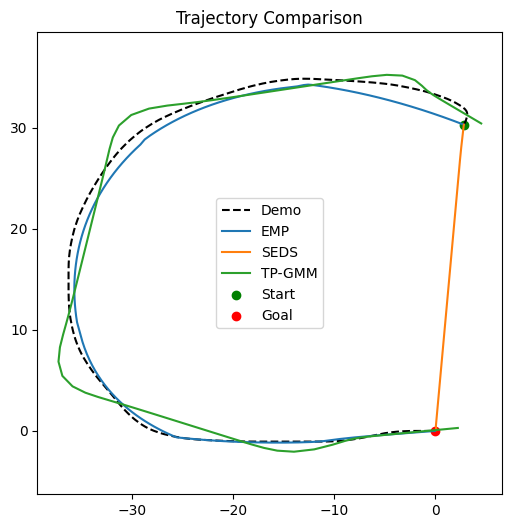

In [63]:
# =========================
# TRAJECTORY PLOT
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.plot(X[:,0], X[:,1], 'k--', label='Demo')
plt.plot(traj_emp[:,0], traj_emp[:,1], label='EMP')
plt.plot(traj_seds[:,0], traj_seds[:,1], label='SEDS')
plt.plot(traj_tpgmm[:,0], traj_tpgmm[:,1], label='TP-GMM')

plt.scatter(*P_start, c='green', label='Start')
plt.scatter(*P_goal, c='red', label='Goal')

plt.legend()
plt.title("Trajectory Comparison")
plt.axis('equal')
plt.show()

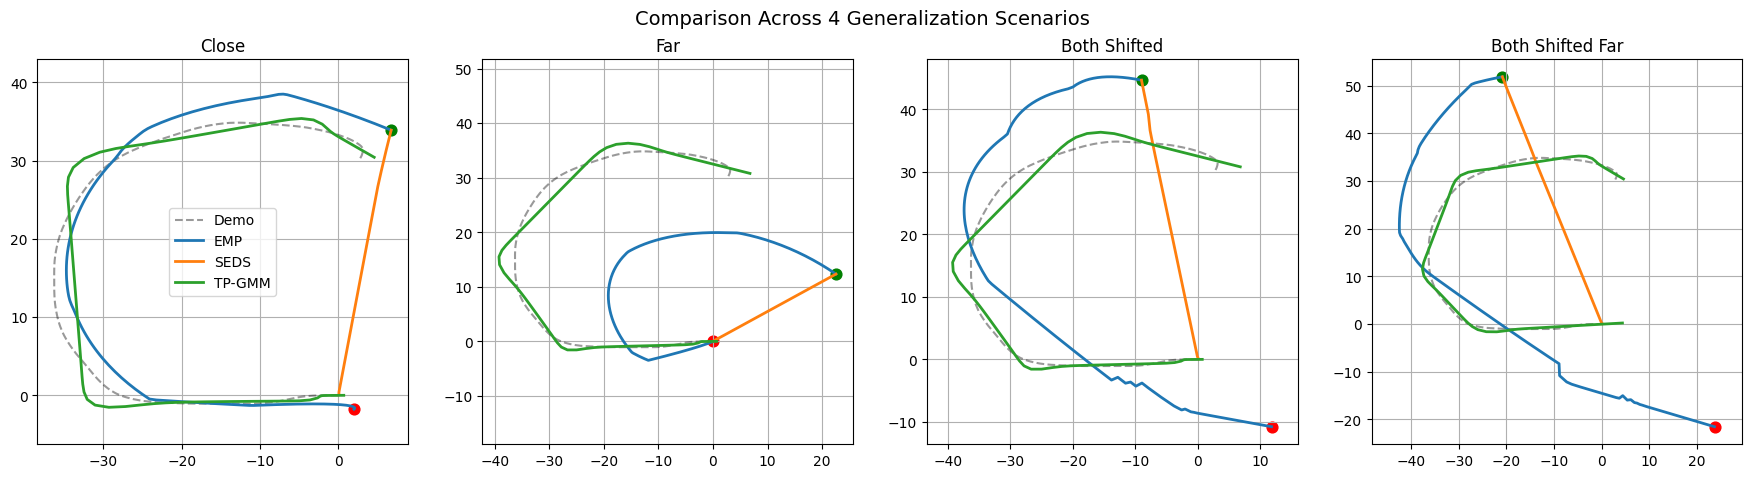

In [64]:
# =========================
# SCENARIOS (PAPER STYLE)
# =========================

span_x = pos[:,0].max() - pos[:,0].min()
span_y = pos[:,1].max() - pos[:,1].min()

scenarios = {
    "Close": dict(
        start = pos[0] + np.array([0.1*span_x, 0.1*span_y]),
        goal  = pos[-1] + np.array([0.05*span_x, -0.05*span_y])
    ),
    "Far": dict(
        start = pos[0] + np.array([0.5*span_x, -0.5*span_y]),
        goal  = pos[-1]
    ),
    "Both Shifted": dict(
        start = pos[0] + np.array([-0.3*span_x, 0.4*span_y]),
        goal  = pos[-1] + np.array([0.3*span_x, -0.3*span_y])
    ),
    "Both Shifted Far": dict(
        start = pos[0] + np.array([-0.6*span_x, 0.6*span_y]),
        goal  = pos[-1] + np.array([0.6*span_x, -0.6*span_y])
    ),
}

# =========================
# PAPER STYLE PLOTS
# =========================

fig, axes = plt.subplots(1, 4, figsize=(22,5))

for ax, (name, sc) in zip(axes, scenarios.items()):

    # --- EMP ---
    emp_policy = adapt_emp(
        sc["start"], sc["goal"],
        joints0, L_mat, Delta0,
        frames0, priors_,
        X, Xdot
    )

    traj_emp_sc = rollout(
        sc["start"],
        emp_policy["means"],
        emp_policy["covs"],
        emp_policy["priors"],
        emp_policy["A_vals"],
        emp_policy["x_star"]
    )

    # --- SEDS ---
    traj_seds_sc = seds.rollout(sc["start"])

    # --- TP-GMM ---
    traj_tpgmm_sc = run_tpgmm(tpgmm_model, pos)

    # --- Plot ---
    ax.plot(pos[:,0], pos[:,1], 'k--', alpha=0.4, label="Demo")

    ax.plot(traj_emp_sc[:,0], traj_emp_sc[:,1], label="EMP", linewidth=2)
    ax.plot(traj_seds_sc[:,0], traj_seds_sc[:,1], label="SEDS", linewidth=2)
    ax.plot(traj_tpgmm_sc[:,0], traj_tpgmm_sc[:,1], label="TP-GMM", linewidth=2)

    ax.scatter(*sc["start"], c='green', s=60)
    ax.scatter(*sc["goal"], c='red', s=60)

    ax.set_title(name)
    ax.axis("equal")
    ax.grid(True)

axes[0].legend()
plt.suptitle("Comparison Across 4 Generalization Scenarios", fontsize=14)
plt.show()

In [65]:
# =========================
# METRICS ACROSS SCENARIOS
# =========================

rows = []

for name, sc in scenarios.items():

    # EMP
    emp_policy = adapt_emp(
        sc["start"], sc["goal"],
        joints0, L_mat, Delta0,
        frames0, priors_,
        X, Xdot
    )

    traj_emp_sc = rollout(
        sc["start"],
        emp_policy["means"],
        emp_policy["covs"],
        emp_policy["priors"],
        emp_policy["A_vals"],
        emp_policy["x_star"]
    )

    traj_seds_sc = seds.rollout(sc["start"])
    traj_tpgmm_sc = run_tpgmm(tpgmm_model, pos)

    m_emp = compute_metrics(traj_emp_sc, pos)
    m_seds = compute_metrics(traj_seds_sc, pos)
    m_tpgmm = compute_metrics(traj_tpgmm_sc, pos)

    rows.append([name, "EMP", *m_emp.values()])
    rows.append([name, "SEDS", *m_seds.values()])
    rows.append([name, "TP-GMM", *m_tpgmm.values()])

df_all = pd.DataFrame(
    rows,
    columns=["Scenario", "Method", "Start Cos ↑", "Goal Cos ↑", "Endpoint Dist ↓"]
)

df_all

,Scenario,Method,Start Cos ↑,Goal Cos ↑,Endpoint Dist ↓
0,Close,EMP,-0.127860,-0.811025,8.015781
1,Close,SEDS,-0.964803,0.339790,5.474992
2,Close,TP-GMM,-0.263134,0.999949,4.689946
3,Far,EMP,0.082833,0.914384,26.722264
4,Far,SEDS,-0.849006,-0.269587,26.814221
5,Far,TP-GMM,-0.267101,0.999949,4.739526
6,Both Shifted,EMP,-0.319812,0.981465,34.573003
7,Both Shifted,SEDS,-0.756970,0.540125,18.751194
8,Both Shifted,TP-GMM,-0.263134,0.999949,4.689946
9,Both Shifted Far,EMP,-0.648039,0.956138,63.972217
